## Métricas para Clasificación

Definimos una función para calcular las métricas en clasificación. En este caso estas métricas solo son para 2 clases. ¿Qué hay que hacer para que sean más clases?

In [ ]:
# Importamos la clase matriz confusión 
# Importación de los métodos requeridos
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
# Importante poner para que se muestren los gráficos
%matplotlib inline
# Definimos una función para utilizarla posteriormente

def obtencion_metricas_clasificacion(Entradas, modelo, Salidas_verdaderas):
    '''Obtención de las métricas de clasificación'''
    # Salidas predichas por el modelo y las salidas verdaderas
    Salidas_predichas = modelo.predict(Entradas)
    matriz_confusion = confusion_matrix(Salidas_verdaderas, Salidas_predichas)
    print("La matriz de confusión es:")
    print(matriz_confusion)

    # Métricas 
    exactitud = accuracy_score(Salidas_verdaderas, Salidas_predichas)
    precision = precision_score(Salidas_verdaderas, Salidas_predichas)
    sensibilidad_recall = recall_score(Salidas_verdaderas, Salidas_predichas)
    puntuacion_f1 = f1_score(Salidas_verdaderas, Salidas_predichas)

    digitos = 4
    print("La exactitud es: ")
    print(round(exactitud,digitos))
    print("La precisión es:")
    print(round(precision,digitos))
    print("La sensibilidad es:")
    print(round(sensibilidad_recall,digitos))
    print("La puntuación F1 es:")
    print(round(puntuacion_f1,digitos))

Definimos una función para mostrar gráficamente la curva ROC

In [ ]:
# Importamos la función precision_recall_curve
from sklearn.metrics import precision_recall_curve
from matplotlib import pyplot as plt
# Importamos las funciones requeridas
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
# Importante poner para que se muestren los gráficos
%matplotlib inline


def dibujar_curva_roc(prob_falsa_alarma, ratio_verdaderos_positivos):
    plt.plot(prob_falsa_alarma, ratio_verdaderos_positivos, "b-", )
    plt.plot([0, 1], [0, 1], 'k--') # Diagonal

    plt.title('Curva ROC')
    plt.xlabel('Probabilidad de falsa alarma (PFA)')
    plt.ylabel('Sensibilidad o ratio verdaderos positivos (TRP)')
    plt.grid()

Así se utilizaría la función. Primero calculo los valores y después llamo a dibujar la curva.

In [ ]:
# Valores necesarios para la curva ROC
prob_falsa_alarma, ratio_verdaderos_positivos, umbrales = roc_curve(y, y_puntuaciones)

In [ ]:
from matplotlib import pyplot as plt
# Dibujamos
dibujar_curva_roc(prob_falsa_alarma, ratio_verdaderos_positivos)
# Para que no se muestren las dos gráficas en la misma figura
plt.show()

## Métricas para Regresión

Definimos una función para calcular las métricas de regresión

In [ ]:
# Importamos las funciones de cálculo de las principales métricas
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Definimos una función para reutilizar posteriormente
def obtencion_metricas_regresion(y, y_sal, titulo_tipo_datos):
    # Error cuadrático medio cometido por la técnica de machine learning
    # Error de entrenamiento
    error_MSE = mean_squared_error(y, y_sal)

    mensaje = 'El error cuadrático medio ' + '' + titulo_tipo_datos + '' + 'es:'
    print(mensaje)
    print(round(error_MSE,4))
                                                
    # Error absoluto medio cometido por la técnica de machine learning
    # Error de entrenamiento
    error_MAE = mean_absolute_error(y, y_sal)

    mensaje = 'El error absoluto medio ' + '' + titulo_tipo_datos + '' + 'es:'
    print(mensaje)
    print(round(error_MAE,4))
                                                
    # Coeficiente de determinación 
    # En el conjunto de datos de entrenamiento
    R2 = r2_score(y, y_sal)

    mensaje = 'El valor del coeficiente de determinación R2 ' + '' + titulo_tipo_datos + '' + 'es:'
    print(mensaje)
    print(round(R2,3))



También podemos mostrar gráficamente como ha sido la predicción en regresión.

In [ ]:
# Función para dibujar los datos de entrada y salida y las predicciones
import matplotlib.pyplot as plt
import numpy as np
def dibuja_ajuste_datos_regresion(x, y, x_entrada, y_sal):
    
    # Ordenamos los valores por si estuvieran desordenados
    indices = np.argsort(x[:,0], axis=0)
    x = x[indices]
    y = y[indices]

    indices = np.argsort(x_entrada[:,0])
    x_entrada = x_entrada[indices]
    y_sal = y_sal[indices]
    
    plt.plot(x, y, "b-", label="Datos")
    plt.plot(x_entrada, y_sal, "m--", label="Predicción")

    plt.title('Curva de datos y predicción de la técnica de Machine Learning')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()



In [ ]:
# Ejemplo de como llamar a la funcióm, está comentado proque no existen las variables  y_test e y_pre
titulo_tipo_datos = 'entrenamiento'
obtencion_metricas_regresion(y_test, y_pre, titulo_tipo_datos)

## Validación de Modelos

### Hold out

Dividir un subconjunto de datos en un % para train y un % para test.

In [ ]:
# Importación del método train_test_split para separar el conjunto total de datos
# en un conjunto de entrenamiento y de test
from sklearn.model_selection import train_test_split

# Seleccionamos un 80% de los datos para entrenamiento y un 20% para test
# X serán las variables de entrada e y las salidas (objetivo) de esas variables.
x_ent, x_test, y_ent, y_test  = train_test_split(X, y, test_size=0.2)

### Hold out con repeticiones

Hay una función en python que me permite dividir aleatoriamente varios conjuntos de test y train para pode rejecutar el modelo varias veces y ver la variabilidad y la consitencia y robustez del modelo. Se trata del iterador ShuffleSplit, este iterador generará un número definido por el usuario de divisiones independientes de conjuntos de datos de entrenamiento / prueba. Las muestras se barajan primero y luego se dividen en un par de conjuntos de entrenamiento y prueba.

Es posible controlar la aleatoriedad para la reproducibilidad de los resultados sembrando explícitamente el generador de números pseudoaleatorios random_state.


In [ ]:
from sklearn.model_selection import ShuffleSplit
X = np.arange(10)
ss = ShuffleSplit(n_splits=5, test_size=0.25, random_state=0)

# Aquí con cada test y train se puede entrenar el modelo y testearlo varias veces.
for train_index, test_index in ss.split(X):
    print("%s %s" % (train_index, test_index))

### Validación cruzada

Permite estimar como test todos los datos, a través de diferentes pruebas. Hay que tener en cuenta que vamos a tener un resultado por cada conjunto de test y luego se mostrará el valor medio.

In [ ]:
# Importamos la clase cross_val_score para realizar la validación cruzada
from sklearn.model_selection import cross_val_score

# El número de subconjuntos (folds) y por tanto el número de veces que se ejecuta el entrenamiento
# El valor por defecto es 5
numero_subconjuntos = 5
# Como función de utilidad tomamos la exactitud total 
# (Las opciones disponibles se pueden consultar 
# en https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter)

###########################################################################3
####IMPORANTE esto es para clasificación, para regresión hay que cambiar la métrica
metrica = "accuracy"
###########################################################################

# El modelo es el clasificador utilizado, se ha tenido que crear previamente
# EL conjunto de datos de entrada que se a dividir en diferentes subconjuntos (folds)
# La función cross_val_score devuelve un nd-array de numpy en el que cada elemento es el acierto de 
# en el conjunto de test
# Se emplean todos los datos x e y
acierto = cross_val_score(modelo, X, y,
                         scoring=metrica, cv=numero_subconjuntos)

# Mostramos los resultados
print("El acierto de cada subconjunto es:")
print(acierto)
# Media
print("La media del acierto es:")
print(round(acierto.mean(),3))
# Desviación estándard 
print("La desviación estándar del acierto es:")
print(round(acierto.std(),3))

Hay otra forma de hacer una validación cruzada en phyton con sklearn. Averigua como se hace y añade el código.

### Leave one out

Cada muestra se utiliza una vez como conjunto de test (singleton), mientras que las muestras restantes forman el conjunto de train.

In [ ]:
import numpy as np
from sklearn.model_selection import LeaveOneOut
X = np.array([[1, 2], [3, 4]])
y = np.array([1, 2])
loo = LeaveOneOut()
loo.get_n_splits(X)
2
print(loo)
LeaveOneOut()
for i, (train_index, test_index) in enumerate(loo.split(X)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")
Fold 0:
  Train: index=[1]
  Test:  index=[0]
Fold 1:
  Train: index=[0]
  Test:  index=[1]

## Técnicas básicas de aprendizaje supervisado

Para ejecutar las técnicas vamos a cargar dos dataset diferentes. Uno para regresión y otro para clasificación. Así ejecutaremos el mismo dataset para todos los algoritmos y podemos proceder a comparar las técnicas.

In [ ]:
# Importación de los módulos necesarios de la biblioteca scikit learn
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


semilla=123
np.random.seed(semilla)

#Dataset para clasificación será IRIS (Clasificación de tipos de flor)
Xiris,yiris = datasets.load_iris(return_X_y=True, as_frame=True)
#iris = pd.concat([datos,etiquetas], axis= 1)
# iris.rename(columns={'target':'especie'}, inplace=True)



#Dataset para regresión será boston (precio viviendas en EEUU)
url = (
    'https://raw.githubusercontent.com/JoaquinAmatRodrigo/Estadistica-machine-learning-python/'
    'master/data/Boston.csv'
)
boston = pd.read_csv(url, sep=',')
Xboston=boston.drop(columns = "MEDV")
yboston=boston['MEDV']
boston.head(3)
# Mostramos el tipo de datos de los atributos por si hubiera que hacer alguna transformación
boston.info()

Vamos a realizar un validación mediante un hold out 80-20. Tanto para regresión como para clasificación.

In [ ]:
from sklearn.model_selection import train_test_split

# Seleccionamos un 80% de los datos para entrenamiento y un 20% para test
# X serán las variables de entrada e y las salidas (objetivo) de esas variables.
x_trainC, x_testC, y_trainC, y_testC  = train_test_split(Xiris, yiris, test_size=0.2)
x_trainR, x_testR, y_trainR, y_testR  = train_test_split(Xboston, yboston, test_size=0.2)

### Árboles de decisión.

Los árboles de decisión  son un método de aprendizaje supervisado no paramétrico que se utiliza para la clasificación y la regresión. El objetivo es crear un modelo que prediga el valor de una variable objetivo mediante el aprendizaje de reglas de decisión sencillas inferidas a partir de las características de los datos. La principal implementación de árboles de decisión en Python está disponible en la librería `scikit-learn` a través de las clases `DecisionTreeClassifier` y `DecisionTreeRegressor`, para los árboles de clasificación y regresión respectivamente. Esta librería necesita convertir todas las variables categóricas en variables dummy (one-hot-encoding). En otras librerías, no es necesaria dicha conversión, pero en scikit-learn, es un paso previo que debe de realizarse.  

#### Clasificación

In [ ]:
from sklearn.tree import DecisionTreeClassifier
modeloC = DecisionTreeClassifier(
            max_depth         = 5,
            criterion         = 'gini',
            random_state      = semilla
          )

modeloC.fit(x_trainC, y_trainC)
print(f"Profundidad del árbol: {modeloC.get_depth()}")
print(f"Número de nodos terminales: {modeloC.get_n_leaves()}")

#### Regresión

In [ ]:
from sklearn.tree import DecisionTreeRegressor
modeloR = DecisionTreeRegressor(
            max_depth         = 3,
            random_state      = semilla
          )

modeloR.fit(x_trainR, y_trainR)


### Máquinas de soporte vectorial
Existen tres clases deSVM en *Scikit-learn* que pueden llevan a cabo la clasificación de clases binarias y de múltiples clases en un conjunto de datos:

- `SVC`: emplea kernels por lo que puede realizar clasificación tanto lineal como no lineal. No es adecuada para conjuntos de datos grandes, por encima de las decenas de miles de datos, ya que el tiempo de entrenamiento aumenta de forma cuadrática con el número de datos del conjunto de entrenamiento.
- `NuSVC`: es similar a SVC, pero posee un parámetro que controla el número de vectores soporte.
- `LinearSVC`: es similar a SVC cuando el kernel de ésta es lineal. Es adecuada para conjuntos de datos grandes. Posee más flexibilidad que SVC en la elección de la función de pérdidas ("loss function")

Para las SVM se recomienda que los datos estén estandarizados.

#### Clasificación

In [ ]:

from sklearn.svm import LinearSVC
# Instanciamos la clase LinearSVC
modelo_SVM_clasif_lineal = LinearSVC(C=1, loss='hinge', random_state=semilla, dual= 'auto')

# Entrenamos la SVM 
modelo_SVM_clasif_lineal.fit(x_trainC, y_trainC)

¿Es correcto, poner sin escalar las variables? ¿Cómo se soluciona?

In [ ]:
# Importamos la clase SVC
from sklearn.svm import SVC

# Instanciamos la clase LinearSVC
SVM_clasif_no_lineal = SVC(kernel='poly', degree=2, C=1, coef0=1,random_state=semilla)


# Entrenamos la SVM kernelizada no lineal
SVM_clasif_no_lineal.fit(x_trainC, y_trainC)

In [ ]:
# Para predecir los valores
y_sal_test = SVM_clasif_no_lineal.predict(x_testC)
y_sal_train = SVM_clasif_no_lineal.predict(x_trainC)
print("TESTTTT---------------------------------------")
obtencion_metricas_clasificacion(x_testC, SVM_clasif_no_lineal, y_testC)


¿Ahora como calculo la precisión? ¿Puedo comparar?

In [ ]:
print("Train---------------------------------------")
obtencion_metricas_clasificacion(x_trainC, SVM_clasif_no_lineal, y_trainC)

#### Regresión

In [ ]:
# Importamos la clase Linear SVR
from sklearn.svm import SVR

# Instancia de la SVM lineal
SVM_no_lineal_reg = SVR(kernel='rbf', gamma=1, epsilon=0.01, C=10)

# Entrenamos la SVM lineal de regresión
SVM_no_lineal_reg.fit(x_trainR, y_trainR)

### Perceptrón Multicapa

El perceptrón multicapa es un tipo de red neuronal en la que existe una capa de entrada, una serie de capas ocultas y una capa de salida. La capa de entrada puede estar compuesta por varias entradas. Asimismo, la capa de salida puede estar compuesta por varias salidas. En la(s) capa(s) oculta(s) las neuronas devuelven el valor de una determinada función de activación para el valor de la entrada de la neurona.

#### Clasificación

In [ ]:
# Importación de la clase MLPCassifier
from sklearn.neural_network import MLPClassifier

# Instanciamos la clase MLPClassifier y generamos el perceptrón multicapa
# con los valores de los parámetros deseados
perceptron_multicapa = MLPClassifier(hidden_layer_sizes=(5), activation='logistic', solver='lbfgs', max_iter=500, learning_rate='invscaling', random_state=semilla)

perceptron_multicapa.fit(x_trainC,y_trainC)

#### Regresión

In [ ]:
# Importamos la clase MLPRegressor
from sklearn.neural_network import MLPRegressor

modelo_multicapa_reg = MLPRegressor(hidden_layer_sizes=(5), 
                                    activation='relu', solver='lbfgs', max_iter=500,
                                    learning_rate='invscaling',
                                    random_state=semilla)
x_trainR, x_testR, y_trainR, y_testR  = train_test_split(Xboston, yboston, test_size=0.2)
modelo_multicapa_reg.fit(x_trainR,y_trainR)

### K Vecinos más cercanos

K-Nearest Neighbors (KNN) es uno de los algoritmos de aprendizaje automático más sencillos e intuitivos. Aunque se suele asociar a tareas de clasificación, KNN también se puede utilizar para tareas de regresión. KNN usa la proximidad para comparar un punto de datos con un set de datos con el que se entrenó y el cual memorizó para realizar predicciones. Este aprendizaje basado en instancias le da a kNN la denominación "aprendizaje vago". kNN funciona sobre la suposición de que los puntos similares pueden encontrarse cerca unos de otros.

#### Clasificación

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 5
 
knn = KNeighborsClassifier(n_neighbors)
knn.fit(x_trainC, y_trainC)
print('Accuracy of K-NN classifier on training set: {:.2f}'
     .format(knn.score(x_trainC, y_trainC)))
print('Accuracy of K-NN classifier on test set: {:.2f}'
     .format(knn.score(x_testC, y_testC)))

#### Regresión

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
neigh = KNeighborsRegressor(n_neighbors=2)
neigh.fit(x_trainR, y_trainR)

## Ajuste de parámetros de las técnicas

Hay varias formas de buscar los parámetros optimos de un algoritmo. Veremos dos de ellos. Primero veremos una búsqueda exhautiva y luego una búsqueda aleatoria:

-  GridSearchCV: Realiza todas las combinaciones posibles entre los parámetros indicados
-  RandomizedSearchCV: No hace todas las combinaciones posibles, sino que coge algunas aleatorias.

Importante poner una semilla para poder reproducir los experimentos

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid


param_grid = {'criterion':['gini','entropy'],
                 'min_samples_split': [2,3,4],
                 'min_samples_leaf': [4,5]
                }
             

# Realizamos la búsqueda por validación cruzada
grid_cv_5 = GridSearchCV(
        # El árbol se crece al máximo posible antes de aplicar el pruning
        estimator = DecisionTreeClassifier(),
        param_grid = param_grid,
        scoring    = 'accuracy',
        cv         = 5
        
      )
# Entrenamos el Grid
grid_cv_5.fit(x_trainC, y_trainC)

# Mostramos los mejores parámetros

arbol_grid = grid_cv_5.best_estimator_
print(grid_cv_5.best_params_)
print(f"Profundidad del árbol: {arbol_grid.get_depth()}")
print(f"Número de nodos terminales: {arbol_grid.get_n_leaves()}")

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint


# Setup the parameters and distributions to sample from: param_dist
param_dist = {"max_depth": [3, None],
              "max_features": randint(1, 9),
              "min_samples_leaf": randint(1, 9),
              "criterion": ["gini", "entropy"]}

# Instantiate a Decision Tree classifier: tree
tree = DecisionTreeClassifier()

# Instantiate the RandomizedSearchCV object: tree_cv
tree_cv = RandomizedSearchCV(tree, param_dist, cv=5,random_state=semilla)

# Fit it to the data
tree_cv.fit(x_trainC,y_trainC)

# Print the tuned parameters and score
print("Tuned Decision Tree Parameters: {}".format(tree_cv.best_params_))
print("Best score is {}".format(tree_cv.best_score_))
y_pred = tree_cv.best_estimator_.predict(x_testC)

# Creamos la matrix de confusion y la imprimimos de forma más gráfica
cm = confusion_matrix(y_testC, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot();

### Crear frontera de decisión

Representar el modelo dibujando la frontera de decisión y visualizando donde están las instancias

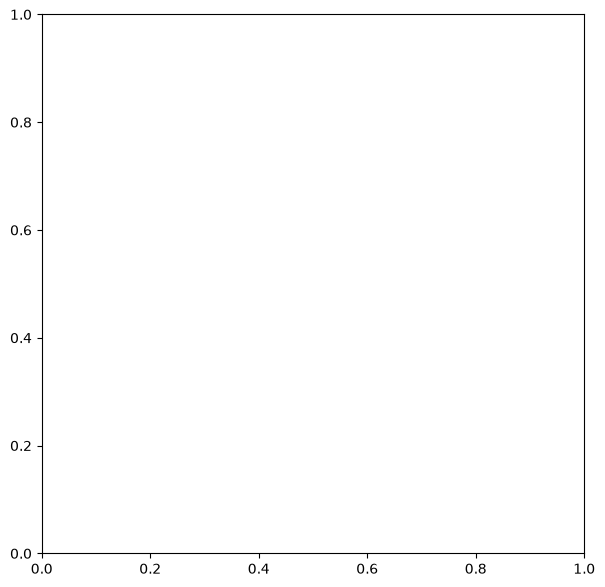

In [109]:
# Frontera de decisión: definimos una función para reutilizar el código
def dibuja_frontera_decision(Entradas, modelo, Salidas, clase_0, clase_1, 
                            colores, etiqueta_leyenda_cero,
                            etiqueta_leyenda_uno, titulo, titulo_eje_x, titulo_eje_y,
                            simbolo, tamano_simbolo, adicion_frontera):
    '''Dibuja las clases y la frontera de decisión generada por la 
    técnica de machine learning'''

    if (adicion_frontera == 1):
        minX1 = min(Entradas[:, 0])       # Valor mínimo de la 1ª característica
        maxX1 = max(Entradas[:, 0])       # Valor máximo de la 1ª característica
        minX2 = min(Entradas[:, 1])       # Valor mínimo de la 2ª característica
        maxX2 = max(Entradas[:, 1])       # Valor máximo de la 2ª característica
        marginX1 = (maxX1 - minX1) * 0.2  # 20% del rango
        marginX2 = (maxX2 - minX2) * 0.2  # para las dos características
        x1 = np.linspace(minX1 - marginX1, maxX1 + marginX1, 1000)  # Vector de coord. X
        x2 = np.linspace(minX2 - marginX2, maxX2 + marginX2, 1000)  # Vector de coord. Y
        X1, X2 = np.meshgrid(x1, x2)       # Generamos las matrices de coordenadas

        # Concatenación con np.c_
        Y = modelo.predict(np.c_[X1.ravel(), X2.ravel()]).reshape(X1.shape)

        
        plt.contourf(X1, X2, Y,levels = 2)

    condicion = Salidas == clase_0
    entradas_clase_0 = Entradas[condicion]
    x1_0 = entradas_clase_0[:,0]
    x2_0 = entradas_clase_0[:,1]
    color_cero = colores[0] 
    plt.scatter(x1_0, x2_0, marker=simbolo, s=tamano_simbolo, color=color_cero, label=etiqueta_leyenda_cero)

    condicion = Salidas == clase_1
    entradas_clase_1 = Entradas[condicion]
    x1_1 = entradas_clase_1[:,0]
    x2_1 = entradas_clase_1[:,1]
    color_uno = colores[1]
    plt.scatter(x1_1, x2_1, marker=simbolo, s=tamano_simbolo, color=color_uno, label=etiqueta_leyenda_uno)

    plt.title(titulo)
    plt.xlabel(titulo_eje_x)
    plt.ylabel(titulo_eje_y)
    plt.legend()

# Figura
fig, ax = plt.subplots(figsize = (7, 7))
# Valores de los parámetros de entrada
clase_0 = 0
clase_1 = 1
colores = ["yellow", "magenta"]
etiqueta_leyenda_cero = 'Ent. clase_0'
etiqueta_leyenda_uno = 'Ent. clase_1'
titulo = "Problema de clasificación binario"
titulo_eje_x = "X1"
titulo_eje_y = "X2"
simbolo = '.'
tamano_simbolo = 50
adicion_frontera = 1


In [ ]:
# Importamos la clase necesaria
from sklearn.datasets import make_classification

# Inicializamos la semilla para reproducibilidad
np.random.seed(1234)


# Número de puntos
numero_puntos = 1000

# Generamos las dos clases
X, y = make_classification(
    n_samples=numero_puntos, n_features=2, n_redundant=0, n_informative=1, 
    n_classes=2, n_clusters_per_class=1, class_sep=0.50)

# Características (features)
x1 = X[:,0]
x2 = X[:,1]
# Y son las etiquetas: valores de 0 y 1. 
# De nuevo una clase está definida con un 0 y la otra clase con un 1
print(y[0:5])

plt.figure(figsize=(7, 7))
plt.subplots_adjust(bottom=0.05, top=0.9, left=0.05, right=0.95)

plt.title("Dos características y dos clases", fontsize="small")
plt.scatter(x1, x2, marker="o", c=y, s=25, edgecolor="k")
plt.xlabel('Característica x1')
plt.ylabel('Característica x2')

In [ ]:
from sklearn.tree import DecisionTreeClassifier
arbol = DecisionTreeClassifier(
            max_depth         = 5,
            criterion         = 'gini',
            random_state      = semilla
          )

arbol.fit(X, y)
print(f"Profundidad del árbol: {arbol.get_depth()}")
print(f"Número de nodos terminales: {arbol.get_n_leaves()}")

In [ ]:
# Así se llamaría a la función, sólo sirve para 2 clases
dibuja_frontera_decision(X, arbol, y, clase_0, clase_1,
                            colores, etiqueta_leyenda_cero,
                            etiqueta_leyenda_uno, titulo, titulo_eje_x, titulo_eje_y,
                            simbolo, tamano_simbolo, adicion_frontera)

In [ ]:
obtencion_metricas_clasificacion(X, arbol, y)

# RETO II


1. Utilizando el dataset preprocesado anteriormente. Emplea  3 técnicas e indica cuál es el mejor modelo. Utiliza un hold out de 70-30, repetido al menos 3 veces. Para comparar emplea al menos 2 métricas. Analiza y justifica los resultados. ¿El modelo es robusto o tiene underfitting u overfitting??
2. Utilizando la función de crear una frontera de decisión, analiza la frontera de decisión de 2 las dos técnicas utilizadas anteriormente . ¿Qué conclusiones se obtienen?

4. Aparte de los métodos de optimización de parámetros estudiados, revisa y describe para que sirven los siguientes:
    - Optuna	
    - BayesSearchCV)	
    - Hyperopt	
    - Ray 


In [110]:
from pathlib import Path
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE
datos = Path("spambase/spambase.data") 
feature_names = [
    "word_freq_make","word_freq_address","word_freq_all","word_freq_3d","word_freq_our",
    "word_freq_over","word_freq_remove","word_freq_internet","word_freq_order","word_freq_mail",
    "word_freq_receive","word_freq_will","word_freq_people","word_freq_report","word_freq_addresses",
    "word_freq_free","word_freq_business","word_freq_email","word_freq_you","word_freq_credit",
    "word_freq_your","word_freq_font","word_freq_000","word_freq_money","word_freq_hp",
    "word_freq_hpl","word_freq_george","word_freq_650","word_freq_lab","word_freq_labs",
    "word_freq_telnet","word_freq_857","word_freq_data","word_freq_415","word_freq_85",
    "word_freq_technology","word_freq_1999","word_freq_parts","word_freq_pm","word_freq_direct",
    "word_freq_cs","word_freq_meeting","word_freq_original","word_freq_project","word_freq_re",
    "word_freq_edu","word_freq_table","word_freq_conference",
    "char_freq_;","char_freq_(","char_freq_[","char_freq_!","char_freq_$","char_freq_#",
    "capital_run_length_average","capital_run_length_longest","capital_run_length_total",
    "spam",
]

In [111]:
df = pd.read_csv(datos, header=None, names=feature_names)
print(df.shape)
print(f"Nulos {df.isna().sum().sum()}")    

print(f"Número de duplicados: {df.duplicated().sum()}")

df = df.drop_duplicates()

X = df.drop(columns=["spam"])
y = df["spam"]


(4601, 58)
Nulos 0
Número de duplicados: 391


In [112]:
df.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
count,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,...,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000
mean,0.104366,0.112656,0.291473,0.063078,0.325321,0.096656,0.117475,0.108000,0.091860,0.248420,...,0.040403,0.144048,0.017376,0.281136,0.076057,0.045798,5.383896,52.139905,291.181948,0.398812
std,0.300005,0.454260,0.515719,1.352487,0.687805,0.276030,0.397284,0.410282,0.282144,0.656638,...,0.252533,0.274256,0.105731,0.843321,0.239708,0.435925,33.147358,199.582168,618.654838,0.489712
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.627500,7.000000,40.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.073000,0.000000,0.016000,0.000000,0.000000,2.297000,15.000000,101.500000,0.000000
75%,0.000000,0.000000,0.440000,0.000000,0.410000,0.000000,0.000000,0.000000,0.000000,0.190000,...,0.000000,0.194000,0.000000,0.331000,0.053000,0.000000,3.706750,44.000000,273.750000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [113]:
print(X[["word_freq_free", "capital_run_length_total"]].describe())

       word_freq_free  capital_run_length_total
count     4210.000000               4210.000000
mean         0.253829                291.181948
std          0.797534                618.654838
min          0.000000                  1.000000
25%          0.000000                 40.000000
50%          0.000000                101.500000
75%          0.127500                273.750000
max         20.000000              15841.000000


precision y FPR para evaluacion metricas

## Arbol de decisión

In [114]:
## Arbol de decisión, KNN y SVM
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

semilla = 42
n_splits = 3

#objeto para escalar
scaler = StandardScaler()

#objeto SSS para hacer hold out con estratificacion 3 veces
sss = StratifiedShuffleSplit(n_splits=n_splits, test_size=0.3, random_state=semilla)

#acumuladores de métricas
acc_dtc, f1_dtc, rec_dtc = [], [], []
acc_knn, f1_knn, rec_knn = [], [], []
acc_svm, f1_svm, rec_svm = [], [], []

i = 1

#bucle para hacer los 3 hold-outs
for train_index, test_index in sss.split(X, y):

    #con los indices devueltos, creamos los conjuntos
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    #escalamos los conjuntos
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    #dtc
    print(f"Árbol Nº{i}")
    dtc = DecisionTreeClassifier(max_depth=5, criterion="gini", random_state=semilla)
    dtc.fit(X_train_sc, y_train)
    y_pred = dtc.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)  
    acc_dtc.append(acc)
    f1_dtc.append(f1)
    rec_dtc.append(rec)

    #knn
    print(f"KNN Nº{i}")
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_sc, y_train)
    y_pred = knn.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    acc_knn.append(acc)
    f1_knn.append(f1)
    rec_knn.append(rec)

    #svm
    print(f"SVM Nº{i}")
    svm = SVC(kernel="rbf", C=1.0, random_state=semilla)
    svm.fit(X_train_sc, y_train)
    y_pred_train = svm.predict(X_train_sc)
    y_pred = svm.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    acc_svm.append(acc)
    f1_svm.append(f1)
    rec_svm.append(rec)

    i += 1

#medias de los 3 
print(f"dtc Acc={sum(acc_dtc)/n_splits} F1={sum(f1_dtc)/n_splits} Recall spam={sum(rec_dtc)/n_splits}")
print(f"knn Acc={sum(acc_knn)/n_splits} F1={sum(f1_knn)/n_splits} Recall spam={sum(rec_knn)/n_splits}")
print(f"svm Acc={sum(acc_svm)/n_splits} F1={sum(f1_svm)/n_splits} Recall spam={sum(rec_svm)/n_splits}")


#comprobar overfiting y underfiting del mejor modelo.

x_train, x_test, y_train, y_test  = train_test_split(X, y, test_size=0.3, random_state=semilla)

#escalamos los conjuntos de entrenamiento y prueba
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)

svm.fit(x_train_sc, y_train)
y_pred_train = svm.predict(x_train_sc)
y_pred_test  = svm.predict(x_test_sc)
print("SVM train Acc:", accuracy_score(y_train, y_pred_train))
print("SVM test  Acc:", accuracy_score(y_test, y_pred_test))
print("SVM train F1 :", f1_score(y_train, y_pred_train))
print("SVM test  F1 :", f1_score(y_test, y_pred_test))

Árbol Nº1
KNN Nº1
SVM Nº1
Árbol Nº2
KNN Nº2
SVM Nº2
Árbol Nº3
KNN Nº3
SVM Nº3
dtc Acc=0.892319873317498 F1=0.8604694570324786 Recall spam=0.832010582010582
knn Acc=0.8957508577461072 F1=0.8635312292956719 Recall spam=0.8267195767195767
svm Acc=0.919767748746371 F1=0.8961765069659596 Recall spam=0.8677248677248678
SVM train Acc: 0.9487614523243977
SVM test  Acc: 0.9144893111638955
SVM train F1 : 0.9332744144940345
SVM test  F1 : 0.893491124260355


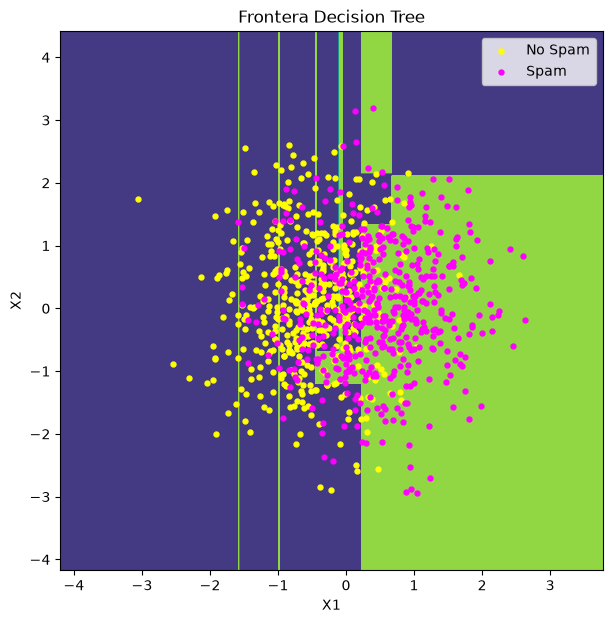

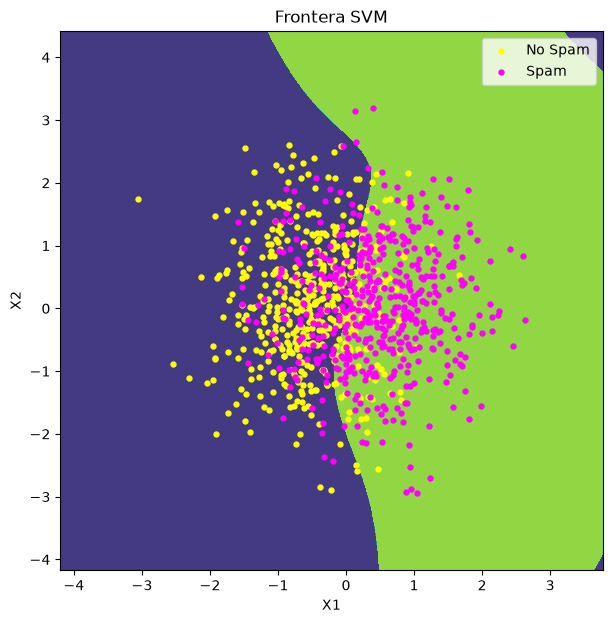

In [123]:
# Importamos la clase necesaria
from sklearn.datasets import make_classification

# Número de puntos
numero_puntos = 1000

# Generamos las dos clases
X2, y2 = make_classification(
    n_samples=numero_puntos, n_features=2, n_redundant=0, n_informative=1, 
    n_classes=2, n_clusters_per_class=1, class_sep=0.50, random_state=semilla )

scaler = StandardScaler()
X2_sc = scaler.fit_transform(X2)

# Técnica 1: Árbol
dtc = DecisionTreeClassifier(max_depth=5, criterion="gini", random_state=semilla)
dtc.fit(X2, y2)

plt.figure(figsize=(7, 7))
dibuja_frontera_decision(
    X2, dtc, y2, clase_0, clase_1, colores,
    "No Spam", "Spam",
    "Frontera Decision Tree", "X1", "X2",
    simbolo, tamano_simbolo, adicion_frontera
)
plt.show()

# Técnica 2: SVM
svm = SVC(kernel="rbf", C=1.0, random_state=semilla)
svm.fit(X2, y2)

plt.figure(figsize=(7, 7))
dibuja_frontera_decision(
    X2, svm, y2, clase_0, clase_1, colores,
    "No Spam", "Spam",
    "Frontera SVM", "X1", "X2",
    simbolo, tamano_simbolo, adicion_frontera
)
plt.show()